<a href="https://colab.research.google.com/github/HoangThai2k5/THDeepLearning/blob/main/Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cài đặt CNN


#2.1. Nạp thư viện

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

#2.2. Đọc dữ liệu MNIST


In [3]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)

X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(19999, 785)
(19999, 784) (19999,) (9999, 784) (9999,)


#Tiền xử lý dữ liệu (Chuẩn hóa và Reshape)

In [4]:
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa giá trị pixel về khoảng [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Chuyển đổi sang numpy array và định hình lại cấu trúc (chuyển về dạng ảnh 2D có 1 kênh màu)
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
print(X_train.shape)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)
print(X_test.shape)

print('Number of classes:', len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


#2.3. Trực quan hóa 10 ảnh đầu tiên

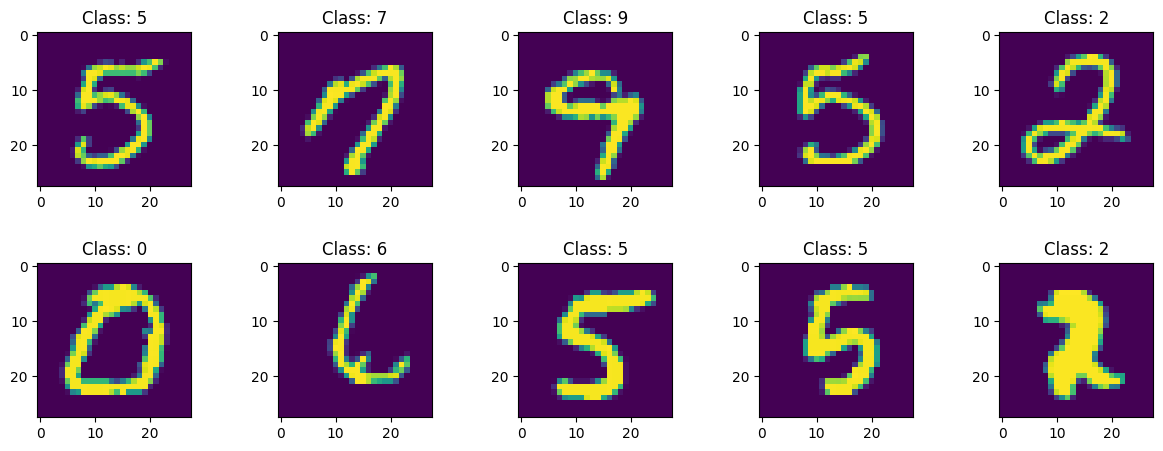

In [5]:
# Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()

for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))

plt.subplots_adjust(hspace=0.5)
plt.show()

#2.4. Chuyển giá trị nhãn thành một-hot encodin

In [6]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

#2.5. Xây dựng mô hình CNN

In [7]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

# 2.6. Huấn luyện mô hình CNN

In [8]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - accuracy: 0.8386 - loss: 0.5810 - val_accuracy: 0.9285 - val_loss: 0.2372
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.9536 - loss: 0.1585 - val_accuracy: 0.9570 - val_loss: 0.1471
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - accuracy: 0.9664 - loss: 0.1061 - val_accuracy: 0.9645 - val_loss: 0.1144
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.9752 - loss: 0.0826 - val_accuracy: 0.9690 - val_loss: 0.0972
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.9799 - loss: 0.0661 - val_accuracy: 0.9705 - val_loss: 0.0845
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 14s 101ms/step - accuracy: 0.9833 - loss: 0.0545 - val_accuracy: 0.9775 - val_loss: 0.0727
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9856 - loss: 0.0460 - val_accuracy: 0.9705 - val_loss: 0.1005
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.9878 - loss: 0

#2.7. Đánh giá độ chính xác và hàm lỗi (Loss) qua biểu đồ

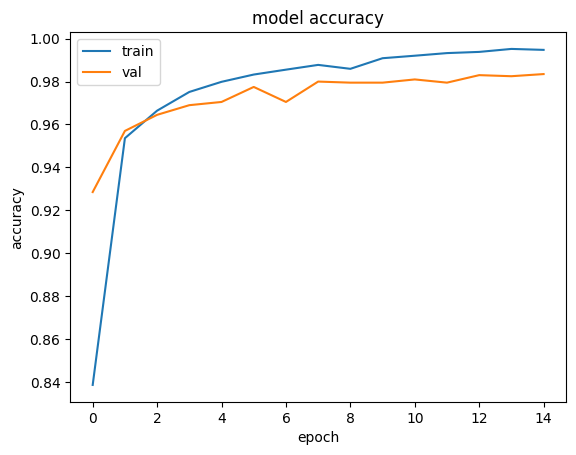

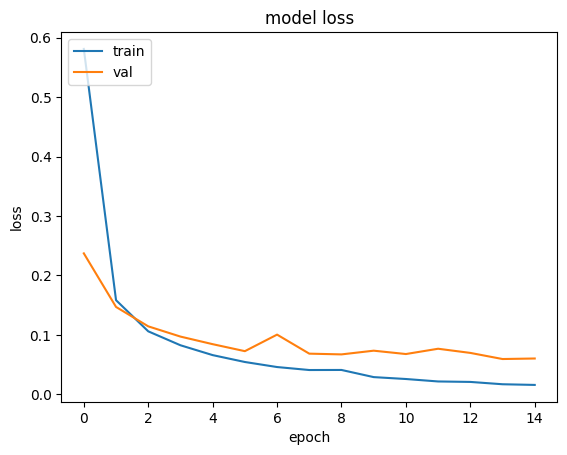

In [9]:
# Biểu đồ độ chính xác (Accuracy)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Biểu đồ hàm lỗi (Loss)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

#2.8. Đánh giá mô hình CNN trên tập dữ liệu kiểm thử (Test set)

In [10]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 5s - 16ms/step - accuracy: 0.9845 - loss: 0.0577
Test loss: 0.05767136812210083
Test accuracy: 0.9844984412193298


#2.9. Dự báo nhãn cho ảnh đầu tiên trong tập Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
[[1.74905750e-07 3.18871412e-06 9.99996662e-01 2.34141699e-11
  3.22279131e-20 2.74676200e-14 4.02530738e-08 1.34397394e-17
  1.37531320e-09 9.43631245e-21]]
2 2


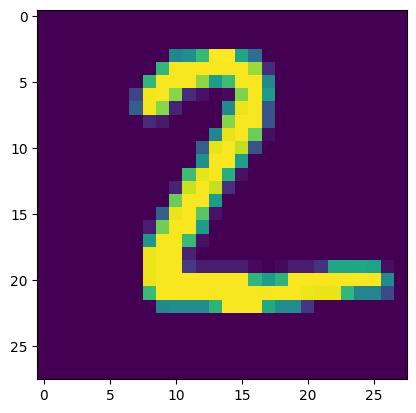

In [11]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))

plt.imshow(X_test[:1].reshape(28, 28))
plt.show()

#2.10 & 2.11. Lưu và Nạp lại trọng số (Weights) mô hình để dự báo ảnh tiếp theo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
[[3.4469346e-07 9.9984562e-01 4.0655163e-05 4.3116032e-07 8.5687701e-05
  1.8721062e-07 3.3717120e-06 4.6473924e-06 1.8905881e-05 2.9594876e-08]]
1 1


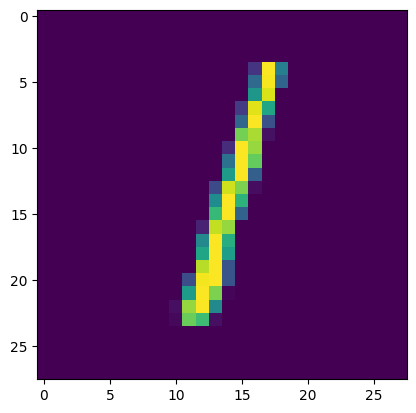

In [13]:
# Lưu tham số mô hình
model.save_weights('cnn.weights.h5')

# Khởi tạo lại cấu trúc mô hình mới
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

# Nạp lại tham số đã lưu
model.load_weights('cnn.weights.h5')

# Dự báo thử nghiệm cho ảnh thứ 2 (chỉ số index là 1) trong tập Test
predict = model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))

plt.imshow(X_test[1:2].reshape(28, 28))
plt.show()

#  CNN để nhận dạng ảnh trên bộ dataset CIFAR10

# 1 Cài đặt thư viện

In [22]:
import numpy as np
import tensorflow as tf
from tensorflow import keras # Unified Keras import
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout # Unified Keras layers
from tensorflow.keras.models import Sequential # Unified Keras models
from tensorflow.keras import Input # Unified Keras Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Added for data augmentation
import matplotlib.pyplot as plt

# 1. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU CIFAR-10

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Kích thước dữ liệu gốc:
Train: (50000, 32, 32, 3) (50000, 1)
Test: (10000, 32, 32, 3) (10000, 1)


/tmp/ipykernel_1774/993670111.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


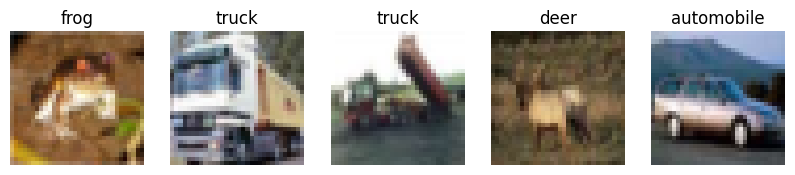

In [15]:

# Tải bộ dữ liệu CIFAR-10 tích hợp sẵn trong TensorFlow
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

print("Kích thước dữ liệu gốc:")
print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

# Định nghĩa danh sách tên các nhãn tương ứng theo yêu cầu đề bài
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Chuẩn hóa giá trị các pixel về khoảng [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Chuyển đổi nhãn từ số nguyên sang dạng One-hot Encoding
num_classes = 10
y_train_label = keras.utils.to_categorical(y_train, num_classes)
y_test_label = keras.utils.to_categorical(y_test, num_classes)

# Trực quan hóa thử 5 ảnh đầu tiên trong tập dữ liệu
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()


# 2. XÂY DỰNG KIẾN TRÚC MÔ HÌNH CNN

In [16]:

model = Sequential()
# Tầng đầu vào (Ảnh CIFAR-10 có kích thước 32x32 pixel và 3 kênh màu RGB)
model.add(Input(shape=(32, 32, 3)))

# Khối Convolutional Layer 1
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25)) # Tránh hiện tượng overfitting

# Khối Convolutional Layer 2
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Tầng phẳng hóa và Fully Connected Layers
model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=num_classes, activation='softmax')) # Tầng đầu ra với hàm Softmax

# Hiển thị cấu trúc chi tiết của mô hình
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

# 3. HUẤN LUYỆN MÔ HÌNH CNN

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Bắt đầu huấn luyện
epochs = 50 # Increased epochs for better performance

# Data Augmentation
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    zoom_range=0.1
)
datagen.fit(X_train)

# Train the model with data augmentation
model_fit = model.fit(
    datagen.flow(X_train, y_train_label, batch_size=64),
    epochs=epochs,
    validation_data=(X_test, y_test_label),
    verbose=1
)

print("Model training complete with data augmentation!")

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 286s 363ms/step - accuracy: 0.6914 - loss: 0.8813 - val_accuracy: 0.7672 - val_loss: 0.6825
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 283s 362ms/step - accuracy: 0.7029 - loss: 0.8543 - val_accuracy: 0.7558 - val_loss: 0.7331
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 280s 358ms/step - accuracy: 0.7032 - loss: 0.8460 - val_accuracy: 0.7119 - val_loss: 0.8816
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 272s 348ms/step - accuracy: 0.7094 - loss: 0.8317 - val_accuracy: 0.7348 - val_loss: 0.7862
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 281s 359ms/step - accuracy: 0.7124 - loss: 0.8241 - val_accuracy: 0.7329 - val_loss: 0.8210
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 278s 356ms/step - accuracy: 0.7167 - loss: 0.8158 - val_accuracy: 0.7496 - val_loss: 0.7579
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 272s 348ms/step - accuracy: 0.7190 - loss: 0.8057 - val_accuracy: 0.7566 - val_loss: 0.7344
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 270s 345ms/step - accuracy: 0.7211 -

# 4. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

313/313 - 12s - 39ms/step - accuracy: 0.7648 - loss: 0.6880

Kết quả đánh giá trên tập Test:
Test loss: 0.6879903078079224
Test accuracy: 0.7648000121116638


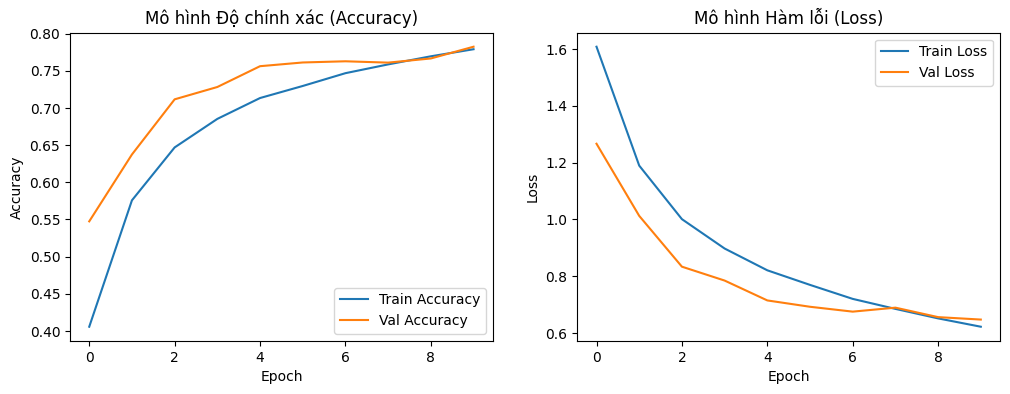

In [18]:
score = model.evaluate(X_test, y_test_label, verbose=2)
print('\nKết quả đánh giá trên tập Test:')
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# Biểu đồ hiển thị sự thay đổi của Accuracy qua các epoch
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(model_fit.history['accuracy'], label='Train Accuracy')
plt.plot(model_fit.history['val_accuracy'], label='Val Accuracy')
plt.title('Mô hình Độ chính xác (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Biểu đồ hiển thị sự thay đổi của Loss qua các epoch
plt.subplot(1, 2, 2)
plt.plot(model_fit.history['loss'], label='Train Loss')
plt.plot(model_fit.history['val_loss'], label='Val Loss')
plt.title('Mô hình Hàm lỗi (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 5. DỰ BÁO THỬ NGHIỆM MỘT ẢNH BẤT KỲ

In [ ]:
# Dự báo ảnh đầu tiên trong tập dữ liệu kiểm thử (Test set)
idx = 0
predict = model.predict(X_test[idx:idx+1])

predicted_class_idx = np.argmax(predict)
actual_class_idx = int(y_test[idx])

print(f"\nKết quả dự đoán ảnh chỉ số {idx}:")
print(f"- Nhãn dự đoán: {class_names[predicted_class_idx]} (Xác suất: {predict[0][predicted_class_idx]*100:.2f}%)")
print(f"- Nhãn thực tế: {class_names[actual_class_idx]}")

# Hiển thị ảnh vừa được dự báo
plt.imshow(X_test[idx])
plt.title(f"Predict: {class_names[predicted_class_idx]} | Actual: {class_names[actual_class_idx]}")
plt.axis('off')
plt.show()